fichier lu : tronque_102s_kalman_D55.50000000000001_V108_Q0.05_R1.5_24_10_2025_2025_10_24_12_18_01_164584.csv
nb points : 931


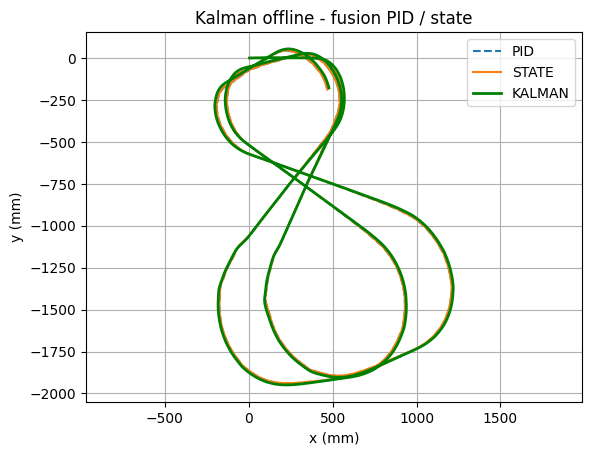

fichier resultats_kalman.csv créé !
erreur PID   : 501.45 mm
erreur state : 499.22 mm
erreur kalman: 505.55 mm


In [ ]:
# TKalman offline
# fusion des données PID et state
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# lecture du fichier de log
# -------------------------------

fichier = "tronque_102s_kalman_D55.50000000000001_V108_Q0.05_R1.5_24_10_2025_2025_10_24_12_18_01_164584.csv"
print("fichier lu :", fichier)

data = pd.read_csv(fichier)
data.columns = [c.strip().lower() for c in data.columns]

x_pid = data["x_pid"]
y_pid = data["y_pid"]

#print(data.columns)
#print(data.head())
#print(x_pid)
x_state = data["x_state"]
y_state = data["y_state"]

n = len(data)
print("nb points :",n)

# -------------------------------
# initialisation du filtre
# -------------------------------
dt = 0.1  # 100ms
x = np.zeros((4,1))
P = np.eye(4)*1000
F = np.array([[1,0,dt,0],
              [0,1,0,dt],
              [0,0,1,0],
              [0,0,0,1]])

Q = np.eye(4)*0.05
H = np.array([[1,0,0,0],
              [0,1,0,0]])

Rpid = np.eye(2)*1.2
Rstate = np.eye(2)*0.8

Xk=[]
Yk=[]

# -------------------------------
# boucle principale
# -------------------------------------------------------------------
for i in range(n):
    
    # prediction
    x = F @ x
    P = F @ P @ F.T + Q
    
    # correction avec state
    z1 = np.array([[x_state.iloc[i]],[y_state.iloc[i]]])
    y1 = z1 - H@x
    S1 = H@P@H.T + Rstate
    K1 = P@H.T@np.linalg.inv(S1)
    x = x + K1@y1
    P = (np.eye(4)-K1@H)@P
    
    # correction avec PID
    z2 = np.array([[x_pid.iloc[i]],[y_pid.iloc[i]]])


    y2 = z2 - H@x
    S2 = H@P@H.T + Rpid
    K2 = P@H.T@np.linalg.inv(S2)
    x = x + K2@y2

    P = (np.eye(4)-K2@H)@P
    
    # sauvegarde
    Xk.append(x[0,0])
    Yk.append(x[1,0])

# -------------------------------
# affichage des courbes
# -------------------------------
plt.figure()
plt.plot(x_pid, y_pid, '--', label="PID")
plt.plot(x_state, y_state, '-', label="STATE")
plt.plot(Xk, Yk, color='green', linewidth=2, label="KALMAN")


plt.legend()
plt.title("Kalman offline - fusion PID / state")
plt.xlabel("x (mm)")




plt.ylabel("y (mm)")
plt.axis("equal")
plt.grid(True)
plt.show()

# -------------------------------
# enregistrement résultat
# -------------------------------
data["x_kalman"] =Xk
data["y_kalman"] = Yk
data.to_csv("resultats_kalman.csv", index=False)
print("fichier resultats_kalman.csv créé !")

